In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Analysis environment ready.")

Analysis environment ready.


In [2]:
try:
    df = pd.read_csv('campus_menu.csv')
    
    df['dietary_label'] = df['dietary_label'].fillna('None')
    df['calories'] = pd.to_numeric(df['calories'], errors='coerce')
    
    print(f"Successfully loaded {len(df)} menu items.")
    display(df.head())
except FileNotFoundError:
    print("Error: campus_menu.csv not found. Run generate_mock_data.py first!")

Successfully loaded 60 menu items.


,item_name,dietary_label,calories,protein_g,carbs_g,fat_g,saturated_fat_g,sodium_mg,fiber_g,added_sugars_g
0,Beef Stir-Fry,None,100,23,8,14,9,391,1,9
1,Steamed Broccoli,"Vegan, Vegetarian, Gluten-Free",425,7,32,15,1,604,5,11
2,French Fries,"Vegetarian, Gluten-Free",588,10,21,4,2,711,7,7
3,Beef Stir-Fry,None,467,16,46,4,8,971,1,12
4,Grilled Chicken Breast,Gluten-Free,481,26,40,14,4,1012,1,7


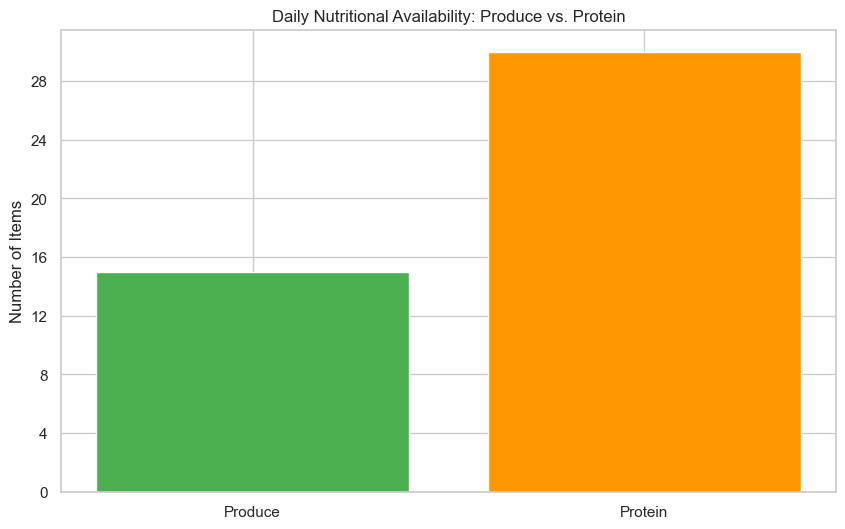

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

produce_keywords = ['Salad', 'Vegetable', 'Fruit', 'Spinach', 'Broccoli', 'Fresh']
protein_keywords = ['Chicken', 'Beef', 'Tofu', 'Beans', 'Turkey', 'Fish', 'Egg', 'Scramble']

df['is_produce'] = df['item_name'].str.contains('|'.join(produce_keywords), case=False)
df['is_protein'] = df['item_name'].str.contains('|'.join(protein_keywords), case=False)

categories = ['Produce', 'Protein']
counts = [df['is_produce'].sum(), df['is_protein'].sum()]

fig, ax = plt.subplots()
ax.bar(categories, counts, color=['#4CAF50', '#FF9800'])

ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Daily Nutritional Availability: Produce vs. Protein')
plt.ylabel('Number of Items')
plt.show()

In [4]:
total_carb_cals = df['carbs_g'].sum() * 4
total_protein_cals = df['protein_g'].sum() * 4
total_fat_cals = df['fat_g'].sum() * 9
total_calculated_cals = total_carb_cals + total_protein_cals + total_fat_cals

pct_carbs = (total_carb_cals / total_calculated_cals) * 100
pct_protein = (total_protein_cals / total_calculated_cals) * 100
pct_fat = (total_fat_cals / total_calculated_cals) * 100

print("--- AMDR MACRONUTRIENT BALANCE REPORT ---")
print(f"Carbohydrates: {pct_carbs:.1f}% (Target: 45-65%) - {'Within AMDR' if 45 <= pct_carbs <= 65 else 'Out of Bounds'}")
print(f"Protein:      {pct_protein:.1f}% (Target: 10-35%) - {'Within AMDR' if 10 <= pct_protein <= 35 else 'Out of Bounds'}")
print(f"Fat:          {pct_fat:.1f}% (Target: 20-35%) - {'Within AMDR' if 20 <= pct_fat <= 35 else 'Out of Bounds'}")

--- AMDR MACRONUTRIENT BALANCE REPORT ---
Carbohydrates: 42.9% (Target: 45-65%) - Out of Bounds
Protein:      17.8% (Target: 10-35%) - Within AMDR
Fat:          39.3% (Target: 20-35%) - Out of Bounds


In [5]:
menu_averages = {
    "Sodium (mg)": df['sodium_mg'].mean(),
    "Saturated Fat (g)": df['saturated_fat_g'].mean(),
    "Added Sugars (g)": df['added_sugars_g'].mean(),
    "Dietary Fiber (g)": df['fiber_g'].mean(),
    "Protein Mass (g)": df['protein_g'].mean()
}

meal_benchmarks = {
    "Sodium (mg)": 766.7,       
    "Saturated Fat (g)": 6.6,    
    "Added Sugars (g)": 10.0,    
    "Dietary Fiber (g)": 9.3,    
    "Protein Mass (g)": 16.6     
}

metric_types = {
    "Sodium (mg)": "Ceiling", "Saturated Fat (g)": "Ceiling", "Added Sugars (g)": "Ceiling",
    "Dietary Fiber (g)": "Floor", "Protein Mass (g)": "Floor"
}

breach_counts = {
    "Sodium (mg)": (df['sodium_mg'] > 766.7).sum(),
    "Saturated Fat (g)": (df['saturated_fat_g'] > 6.6).sum(),
    "Added Sugars (g)": (df['added_sugars_g'] > 10.0).sum(),
    "Dietary Fiber (g)": (df['fiber_g'] < 9.3).sum(),       
    "Protein Mass (g)": (df['protein_g'] < 16.6).sum()       
}

summary_data = []
for metric in menu_averages:
    avg = menu_averages[metric]
    target = meal_benchmarks[metric]
    m_type = metric_types[metric]
    breaches = breach_counts[metric]
    
    pct_diff = ((avg - target) / target) * 100
    
    if m_type == "Ceiling":
        status = "Exceeds Target" if avg > target else "Safe"
        breach_label = "Items Breaching Ceiling"
    else:
        status = "Meets Target" if avg >= target else "Deficit"
        breach_label = "Items in Deficit"
        
    summary_data.append({
        "Nutrient Metric": metric,
        "Menu Average": round(avg, 1),
        "Meal Benchmark (1/3 DV)": round(target, 1),
        "Pct Deviation": f"{pct_diff:+.1f}%",
        "Aggregate Status": status,
        breach_label: f"{breaches} / {len(df)} items"
    })

summary_df = pd.DataFrame(summary_data)
print("--- GUIDELINE COMPARISON SUMMARY ---")
display(summary_df)

amdr_pass = (45 <= pct_carbs <= 65) and (10 <= pct_protein <= 35) and (20 <= pct_fat <= 35)
print(f"\nOverall Menu AMDR Alignment Compliant: {amdr_pass}")

--- GUIDELINE COMPARISON SUMMARY ---


,Nutrient Metric,Menu Average,Meal Benchmark (1/3 DV),Pct Deviation,Aggregate Status,Items Breaching Ceiling,Items in Deficit
0,Sodium (mg),609.0,766.7,-20.6%,Safe,21 / 60 items,NaN
1,Saturated Fat (g),3.7,6.6,-43.9%,Safe,11 / 60 items,NaN
2,Added Sugars (g),7.0,10.0,-29.7%,Safe,13 / 60 items,NaN
3,Dietary Fiber (g),3.3,9.3,-64.3%,Deficit,NaN,60 / 60 items
4,Protein Mass (g),13.0,16.6,-21.7%,Deficit,NaN,46 / 60 items



Overall Menu AMDR Alignment Compliant: False


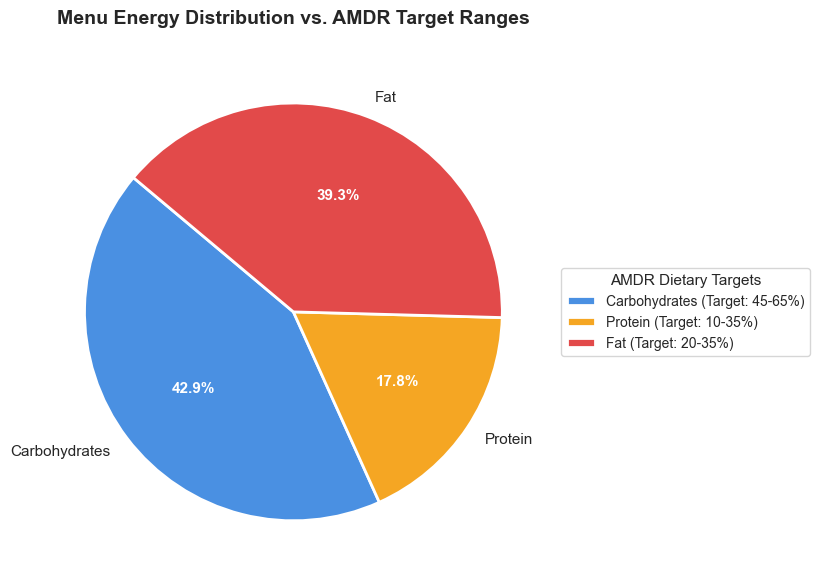

In [6]:
labels = ['Carbohydrates', 'Protein', 'Fat']
sizes = [pct_carbs, pct_protein, pct_fat]
colors = ['#4a90e2', '#f5a623', '#e24a4a']

fig, ax = plt.subplots(figsize=(8, 6))

wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True},
    textprops={'fontsize': 11}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')

legend_labels = [
    "Carbohydrates (Target: 45-65%)",
    "Protein (Target: 10-35%)",
    "Fat (Target: 20-35%)"
]

ax.legend(
    wedges, 
    legend_labels, 
    title="AMDR Dietary Targets", 
    loc="center left", 
    bbox_to_anchor=(1, 0, 0.5, 1), 
    fontsize=10, 
    title_fontsize=11
)

plt.title('Menu Energy Distribution vs. AMDR Target Ranges', fontsize=14, pad=20, weight='bold')
plt.tight_layout()
plt.show()

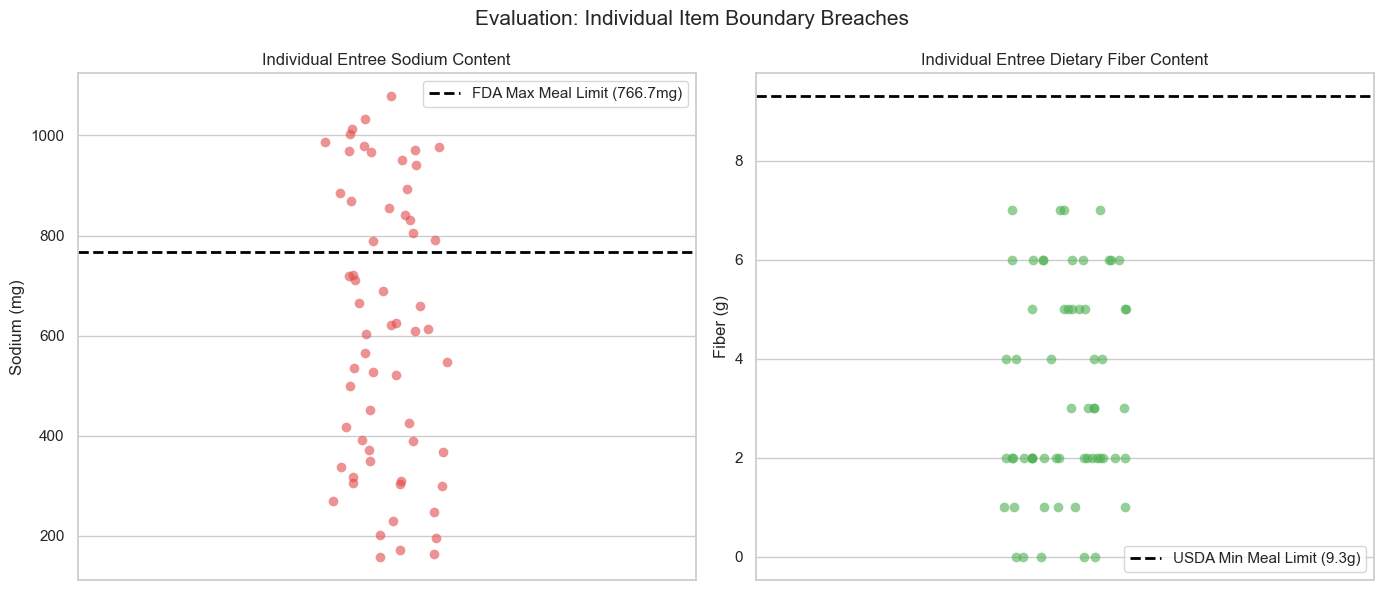

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.stripplot(data=df, y='sodium_mg', color='#e24a4a', alpha=0.6, size=7, ax=axes[0])
axes[0].axhline(y=766.7, color='black', linestyle='--', linewidth=2, label='FDA Max Meal Limit (766.7mg)')
axes[0].set_title('Individual Entree Sodium Content', fontsize=12)
axes[0].set_ylabel('Sodium (mg)')
axes[0].legend(loc='upper right')

sns.stripplot(data=df, y='fiber_g', color='#4caf50', alpha=0.6, size=7, ax=axes[1])
axes[1].axhline(y=9.3, color='black', linestyle='--', linewidth=2, label='USDA Min Meal Limit (9.3g)')
axes[1].set_title('Individual Entree Dietary Fiber Content', fontsize=12)
axes[1].set_ylabel('Fiber (g)')
axes[1].legend(loc='lower right')

plt.suptitle('Evaluation: Individual Item Boundary Breaches', fontsize=15, y=0.98)
plt.tight_layout()
plt.show()

In [8]:
print("--- NUTRITIONAL VARIANCE ANALYSIS ---")

variance_cols = ['sodium_mg', 'added_sugars_g', 'saturated_fat_g', 'calories']
for col in variance_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

variance_summary = df[variance_cols].agg(['mean', 'std', 'min', 'max']).round(1)
display(variance_summary)

--- NUTRITIONAL VARIANCE ANALYSIS ---


,sodium_mg,added_sugars_g,saturated_fat_g,calories
mean,609.0,7.0,3.7,351.6
std,277.6,4.0,3.2,181.9
min,158.0,0.0,0.0,81.0
max,1078.0,13.0,13.0,633.0



--- PHASE 2: DIETARY TAX EVALUATION ---


protein_g       sodium_mg       calories      
                                    mean count      mean count     mean count
dietary_label                                                                
Gluten-Free                         28.2     9     540.7     9    355.6     9
None                                21.5     8     640.6     8    302.1     8
Vegan, Gluten-Free                   6.8     5     644.4     5    522.0     5
Vegan, Vegetarian                    8.6     9     685.7     9    336.6     9
Vegan, Vegetarian, Gluten-Free       8.8    10     555.6    10    266.7    10
Vegetarian                           8.7    11     600.5    11    351.2    11
Vegetarian, Gluten-Free              7.4     8     624.4     8    414.1     8

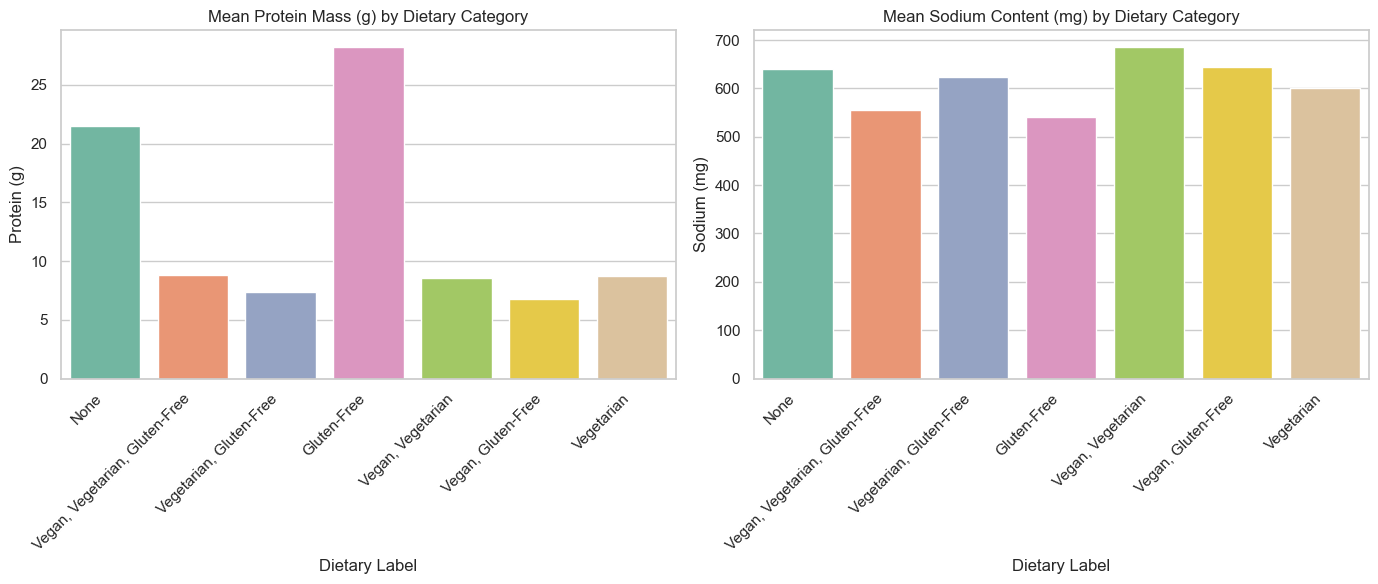

In [ ]:
print("\n--- DIETARY TAX EVALUATION ---")

dietary_tax_df = df.groupby('dietary_label')[['protein_g', 'sodium_mg', 'calories']].agg(['mean', 'count']).round(1)
display(dietary_tax_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=df, 
    x='dietary_label', 
    y='protein_g', 
    ax=axes[0], 
    errorbar=None, 
    hue='dietary_label', 
    palette='Set2', 
    legend=False
)
axes[0].set_title('Mean Protein Mass (g) by Dietary Category')
axes[0].set_ylabel('Protein (g)')
axes[0].set_xlabel('Dietary Label')

axes[0].tick_params(axis='x', rotation=45)
for label in axes[0].get_xticklabels():
    label.set_horizontalalignment('right')

sns.barplot(
    data=df, 
    x='dietary_label', 
    y='sodium_mg', 
    ax=axes[1], 
    errorbar=None, 
    hue='dietary_label', 
    palette='Set2', 
    legend=False
)
axes[1].set_title('Mean Sodium Content (mg) by Dietary Category')
axes[1].set_ylabel('Sodium (mg)')
axes[1].set_xlabel('Dietary Label')

axes[1].tick_params(axis='x', rotation=45)
for label in axes[1].get_xticklabels():
    label.set_horizontalalignment('right')

plt.tight_layout()
plt.show()


--- DENSITY DISTRIBUTIONS ---


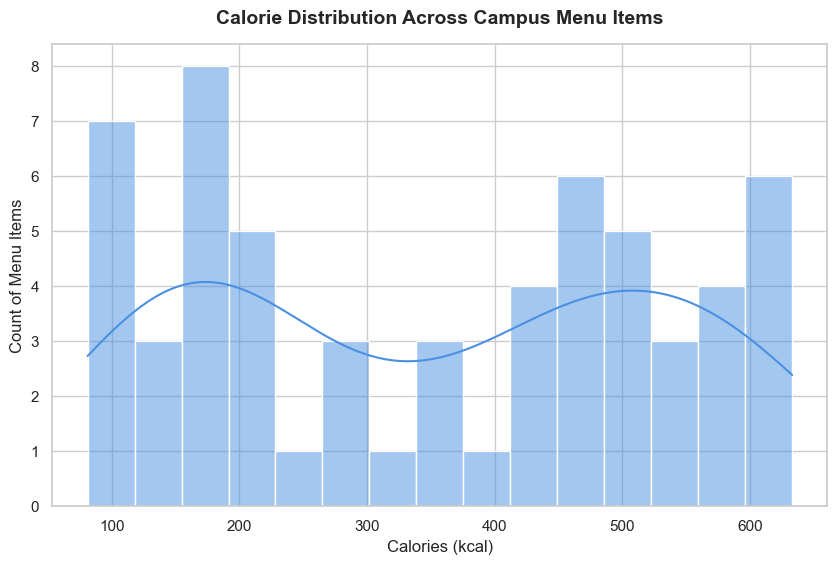

In [ ]:
print("\n--- DENSITY DISTRIBUTIONS ---")

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='calories', kde=True, bins=15, color='#4a90e2', edgecolor='white')

plt.title('Calorie Distribution Across Campus Menu Items', fontsize=14, weight='bold', pad=15)
plt.xlabel('Calories (kcal)')
plt.ylabel('Count of Menu Items')
plt.show()